# Importing Libraries 

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Reading and Cleaning Data

In [48]:
data = pd.read_csv("X:\\VScode\\Artificial_intelligence_n_Machine_learning\\Projects\\CreditWise_Loan_System\\loan_approval_data.csv")
data = pd.DataFrame(data)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [50]:
categorical_col= data.select_dtypes(include=["object"]).columns
numerical_cols = data.select_dtypes(include=["number"]).columns

In [51]:
num_imp = SimpleImputer(strategy="mean")
data[numerical_cols] = num_imp.fit_transform(data[numerical_cols])

In [52]:
cat_imp = SimpleImputer(strategy="most_frequent")
data[categorical_col] = cat_imp.fit_transform(data[categorical_col])

In [53]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [54]:
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

EDA - Exploratory Data Analysis

Text(0.5, 1.0, 'Loan Approved Yes or No')

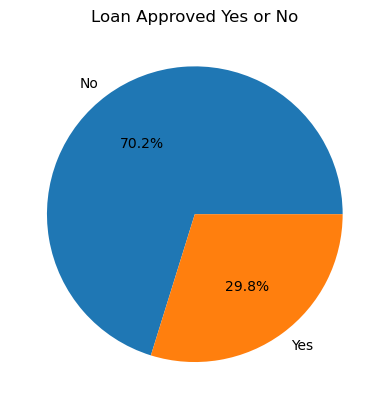

In [55]:
count = data["Loan_Approved"].value_counts()
plt.pie(count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Loan Approved Yes or No")

# Analyze Income

<Axes: xlabel='Applicant_Income', ylabel='Count'>

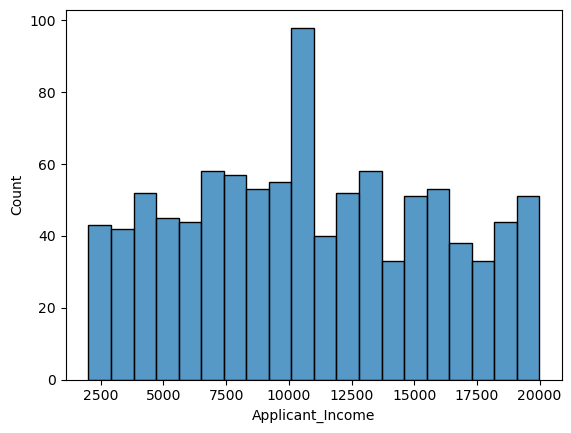

In [56]:
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

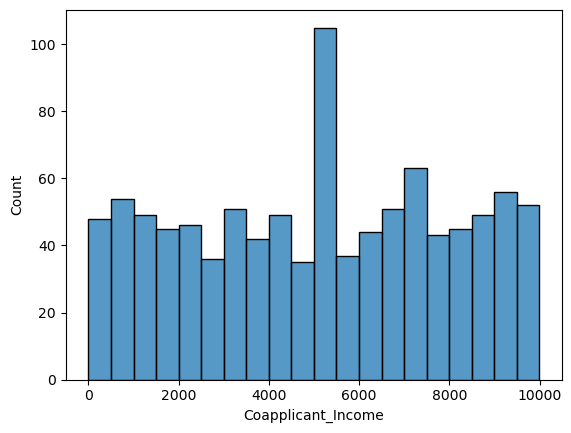

In [57]:
sns.histplot(
    data = data,
    x = "Coapplicant_Income",
    bins = 20
)

outliers

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

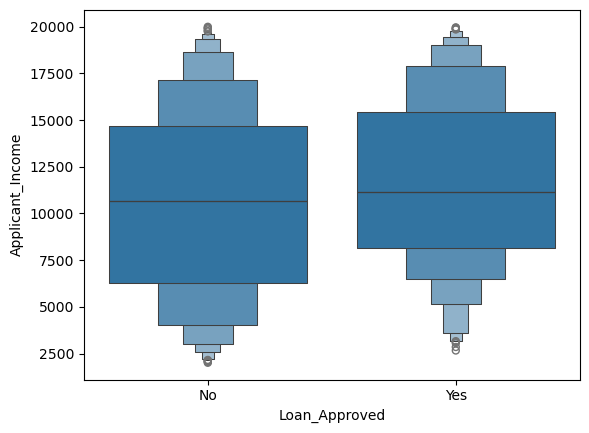

In [58]:
sns.boxenplot(
    data=data,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

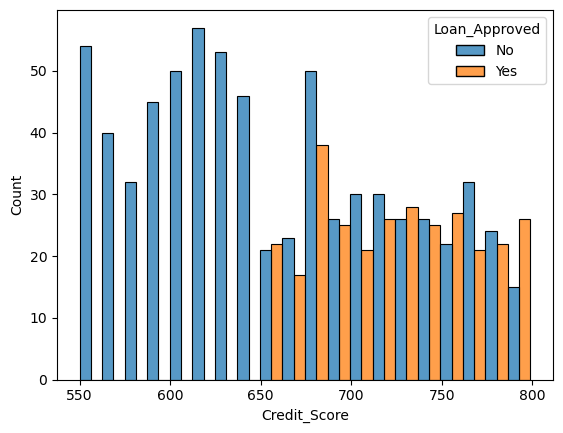

In [59]:
sns.histplot(
    data = data,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple="dodge"
)

Removing Useless data who will not affect model performance

In [60]:
data = data.drop("Applicant_ID",axis=1)
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [61]:
# LabelEncoding - ordinal data - Ordered

Le = LabelEncoder()
data["Education_Level"] = Le.fit_transform(data["Education_Level"])
data["Loan_Approved"] = Le.fit_transform(data["Loan_Approved"])

In [62]:
# OneHotEncoding - nominal data - no Order
cols = ["Employment_Status","Loan_Purpose","Property_Area","Education_Level","Marital_Status","Gender","Employer_Category","Loan_Approved"]
ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore",
)
encoded = ohe.fit_transform(data[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols),index=data.index)
data = pd.concat([data.drop(columns=cols), encoded_df], axis=1)

In [63]:
data.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Education_Level_1,Marital_Status_Single,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Approved_1
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


In [64]:
data = pd.DataFrame(data)

# Correlation Heatmap 

# Correlation value ranges from -1 to 1

1 is prefect positive correlation

-1 is perfect negative correlation 

0 is no linear correlation

<Axes: >

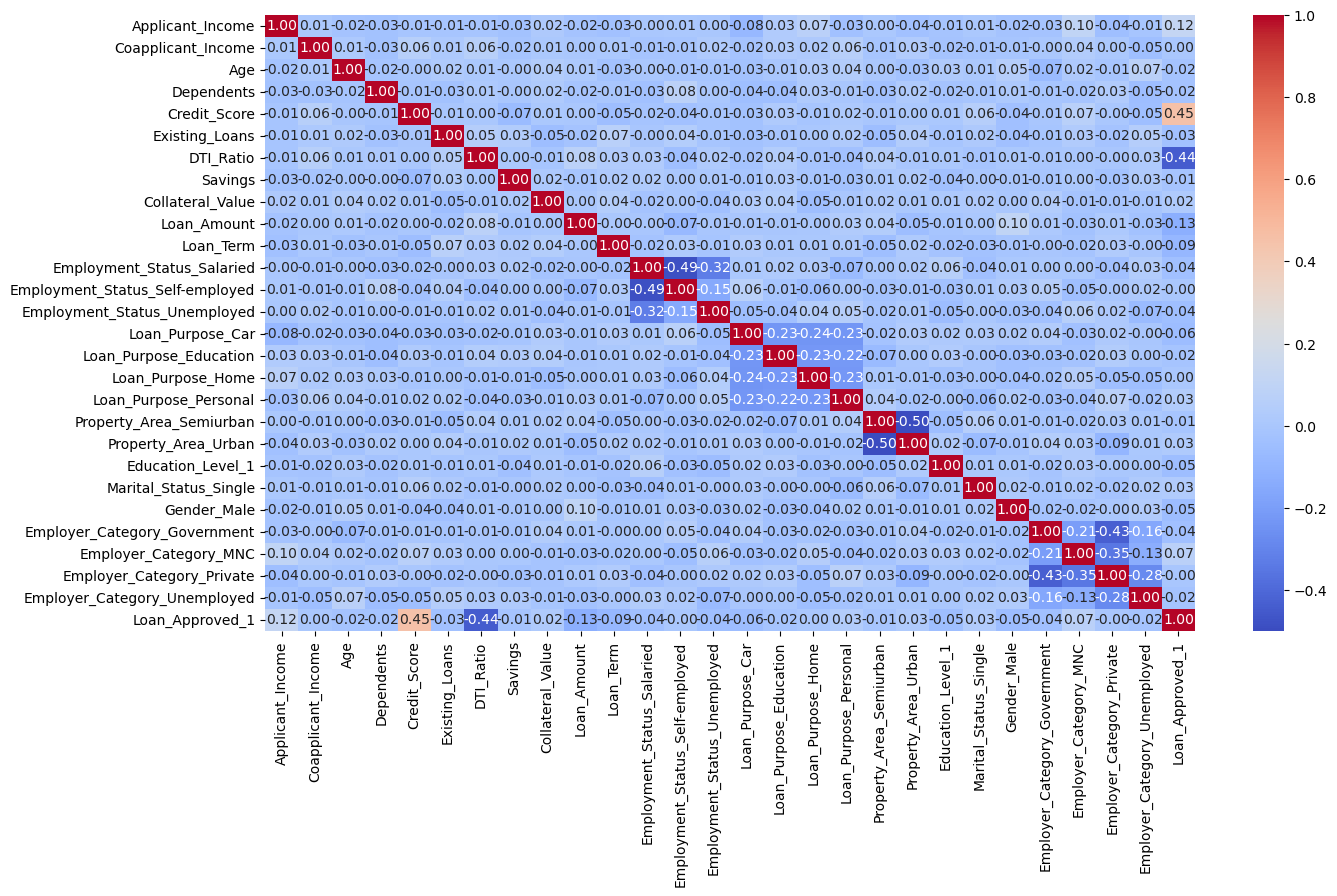

In [65]:
nums_cols = data.select_dtypes(include="number")
corr_marx = nums_cols.corr()
corr_marx
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_marx,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [66]:
nums_cols.corr()["Loan_Approved_1"].sort_values(ascending=False)

Loan_Approved_1                    1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level_1               

In [67]:
X = data.drop("Loan_Approved_1",axis=1)
y = data["Loan_Approved_1"]

In [68]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_1,Marital_Status_Single,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [69]:
y.head()

0    0.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Loan_Approved_1, dtype: float64

# Train test model

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)

In [71]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.fit_transform(X_test)

# Logistic Regression

In [72]:
# train
log_model = LogisticRegression()
log_model.fit(X_train_scaler, y_train)
y_pred = log_model.predict(X_test_scaler)# Evalate 
print("Logistic Regression")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall:{recall_score(y_test,y_pred):.4f}")
print(f"F1 score:{f1_score(y_test,y_pred):.4f}")
print(f"Accuracy:{accuracy_score(y_test,y_pred):.4f}")
print(f"Confusion Matrix:{confusion_matrix(y_test,y_pred)}")

Logistic Regression
Precision: 0.8519
Recall:0.7541
F1 score:0.8000
Accuracy:0.8850
Confusion Matrix:[[131   8]
 [ 15  46]]


# KNN

In [73]:
kn_model = KNeighborsClassifier(n_neighbors=5)
kn_model.fit(X_train_scaler, y_train)

y_pred = kn_model.predict(X_test_scaler)

# Evalate
print("KNN model")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall:{recall_score(y_test,y_pred):.4f}")
print(f"F1 score:{f1_score(y_test,y_pred):.4f}")
print(f"Accuracy:{accuracy_score(y_test,y_pred):.4f}")
print(f"Confusion Matrix:{confusion_matrix(y_test,y_pred)}")

KNN model
Precision: 0.6087
Recall:0.4590
F1 score:0.5234
Accuracy:0.7450
Confusion Matrix:[[121  18]
 [ 33  28]]


# Naive Bayes

In [74]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaler,y_train)

y_pred = nb_model.predict(X_test_scaler)

print("Naive Bayes model")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall:{recall_score(y_test,y_pred):.4f}")
print(f"F1 score:{f1_score(y_test,y_pred):.4f}")
print(f"Accuracy:{accuracy_score(y_test,y_pred):.4f}")
print(f"Confusion Matrix:{confusion_matrix(y_test,y_pred)}")

Naive Bayes model
Precision: 0.7778
Recall:0.6885
F1 score:0.7304
Accuracy:0.8450
Confusion Matrix:[[127  12]
 [ 19  42]]


# Best model for this data is Naive bayes
# Feature Engineering

In [80]:
data["Loan_Approved"] = data["Loan_Approved_1"]
data["DTI_Ratio1"] = data["DTI_Ratio"] ** 2
data["Credit_Score1"] = data["Credit_Score"] ** 2
data["Applicant_Income1"] = np.log1p(data["Applicant_Income"])

X = data.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score","Applicant_Income"], axis=1)
y = data["Loan_Approved"]

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.fit_transform(X_test)

In [81]:
X_train.head()

,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Employment_Status_Salaried,Employment_Status_Self-employed,...,Marital_Status_Single,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Approved_1,DTI_Ratio1,Credit_Score1,Applicant_Income1
29,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181
535,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196
695,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0484,341056.000000,9.292249
557,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954
836,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0324,457021.542187,8.561975


# Checking model Performance after Feature Engineering

In [82]:
# train
log_model = LogisticRegression()
log_model.fit(X_train_scaler, y_train)
y_pred = log_model.predict(X_test_scaler)# Evalate 
print("Logistic Regression")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall:{recall_score(y_test,y_pred):.4f}")
print(f"F1 score:{f1_score(y_test,y_pred):.4f}")
print(f"Accuracy:{accuracy_score(y_test,y_pred):.4f}")
print(f"Confusion Matrix:{confusion_matrix(y_test,y_pred)}")

Logistic Regression
Precision: 1.0000
Recall:1.0000
F1 score:1.0000
Accuracy:1.0000
Confusion Matrix:[[139   0]
 [  0  61]]


In [83]:
kn_model = KNeighborsClassifier(n_neighbors=5)
kn_model.fit(X_train_scaler, y_train)

y_pred = kn_model.predict(X_test_scaler)

# Evalate
print("KNN model")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall:{recall_score(y_test,y_pred):.4f}")
print(f"F1 score:{f1_score(y_test,y_pred):.4f}")
print(f"Accuracy:{accuracy_score(y_test,y_pred):.4f}")
print(f"Confusion Matrix:{confusion_matrix(y_test,y_pred)}")

KNN model
Precision: 0.9649
Recall:0.9016
F1 score:0.9322
Accuracy:0.9600
Confusion Matrix:[[137   2]
 [  6  55]]


In [84]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaler,y_train)

y_pred = nb_model.predict(X_test_scaler)

print("Naive Bayes model")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall:{recall_score(y_test,y_pred):.4f}")
print(f"F1 score:{f1_score(y_test,y_pred):.4f}")
print(f"Accuracy:{accuracy_score(y_test,y_pred):.4f}")
print(f"Confusion Matrix:{confusion_matrix(y_test,y_pred)}")

Naive Bayes model
Precision: 1.0000
Recall:1.0000
F1 score:1.0000
Accuracy:1.0000
Confusion Matrix:[[139   0]
 [  0  61]]
